<a href="https://colab.research.google.com/github/CelestialSteel/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Practical Exercise 2: Data Cleaning

#### 1. Download and upload the Airplane Crashes Dataset from Kaggle.

In [40]:
import pandas as pd

df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")

#### 2. Determine the number of rows and columns in the dataset.

In [41]:
df.shape

(5268, 13)

#### 3. Display the last 75 rows in the dataset.


In [42]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


#### 4. Each column except the first one has some missing data. For each column, name the most appropriate method for treating the missing data. Justify your choices.


In [43]:
print(df.isnull().sum())

Date               0
Time            2219
Location          20
Operator          18
Flight #        4199
Route           1707
Type              27
Registration     335
cn/In           1228
Aboard            22
Fatalities        12
Ground            22
Summary          390
dtype: int64


**Time** - Impute with unknown - Since the time of the crash is critical to understanding the cause and factors that may have caused the crash at that time.  
**Location** - Drop missing values - since the column has very few missing values (20 missing values).   
**Operator** - Drop missing values  - Since it had a few missing values it would be safer to drop the missing values.   
**Flight Number** - Drop Column - The data has too many missing values and it is unlikely to be helpful in predicting meaningful outcomes (4199 missing values).
**Route** - Drop column - Since the data can't be inferred, imputing with unknown would lead to inaccuracies later on.    
**Type of aircraft** - Drop missing values - It only has 27 missing values, thus dropping them would be beneficial.   
**Registration** - Drop missing values - Since the aircraft registration is a unique identifier it can not be imputed, thus all missing values can be removed.  
**cn/In** - drop column -  Since it fulfils a similar task to the registration number and has multiple missing values dropping the column would be best to avoid tracking unnecessary values (1228 missing values).  
**Aboard** - Impute with Median value - Since the number of passengers aboard an aircraft is critical information, it can be imputed with the median value to have a well represented estimation.   
**Fatalities** - Impute with Median - Since there are only 12 missing values and the fatality data is important it can be estimated with the median and imputed for an effective dataset.  
**Ground** - Impute with median - Given that the number of ground mortalities is low, it can be estimated using the median for accurate data representation.

#### 5. Create a new dataframe from the raw/uncleaned data called ‘fatality_locations’ with the following columns: ‘Date’, ‘Location’, ‘Aboard’, ‘Fatalities’.

In [44]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]

#### 6. Determine the date of the highest number of recorded fatalities from this new dataframe.

In [45]:
fatality_locations.loc[
    fatality_locations['Fatalities'].idxmax(),
    'Date'
]

'03/27/1977'

#### 7. Compare the number of passengers aboard to the number of fatalities per crash. Are there any recorded crashes where there were no fatalities? If so, how many?

In [50]:
fatality_locations[['Aboard', 'Fatalities']]

no_fatalities = fatality_locations[
    fatality_locations['Fatalities'] == 0
]

print("Number of crashes with no fatalities:", no_fatalities.shape[0])

Number of crashes with no fatalities: 58


#### 8. In the ‘fatality_locations’ dataframe, the location column has data items represented as ‘Region, U.S. State/Country’. Split this column to have two columns of regions and states/countries.

In [51]:
import numpy as np

# Split from the last comma
split_data = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

# Split regions and state_country according to presence of a comma, otherwise it goes to State_Country
fatality_locations['Region'] = np.where(split_data[1].isna(), "", split_data[0].str.strip())
fatality_locations['State_Country'] = np.where(split_data[1].isna(), split_data[0].str.strip(), split_data[1].str.strip())

# Print results
print(fatality_locations[['Location', 'Region', 'State_Country']].head())


                             Location                      Region  \
0                 Fort Myer, Virginia                   Fort Myer   
1             AtlantiCity, New Jersey                 AtlantiCity   
2  Victoria, British Columbia, Canada  Victoria, British Columbia   
3                  Over the North Sea                               
4          Near Johannisthal, Germany           Near Johannisthal   

        State_Country  
0            Virginia  
1          New Jersey  
2              Canada  
3  Over the North Sea  
4             Germany  


C:\Users\micha\AppData\Local\Temp\ipykernel_420\4261593883.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations['Region'] = np.where(split_data[1].isna(), "", split_data[0].str.strip())
C:\Users\micha\AppData\Local\Temp\ipykernel_420\4261593883.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fatality_locations['State_Country'] = np.where(split_data[1].isna(), split_data[0].str.strip(), split_data[1].str.strip())


#### 9. Order the dataframe by the number of fatalities from highest to lowest and select the first 100.

In [48]:
fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

,Date,Location,Aboard,Fatalities
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0
...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0
1433,06/30/1956,"Grand Canyon, Arizona",128.0,128.0
3970,10/02/1990,"Guangzhou, China",226.0,128.0


#### 10. Generate a pie chart that shows the distribution of the top 25 number of fatalities per country/U.S. State. [Hint: charts can be generated from the seaborn library]

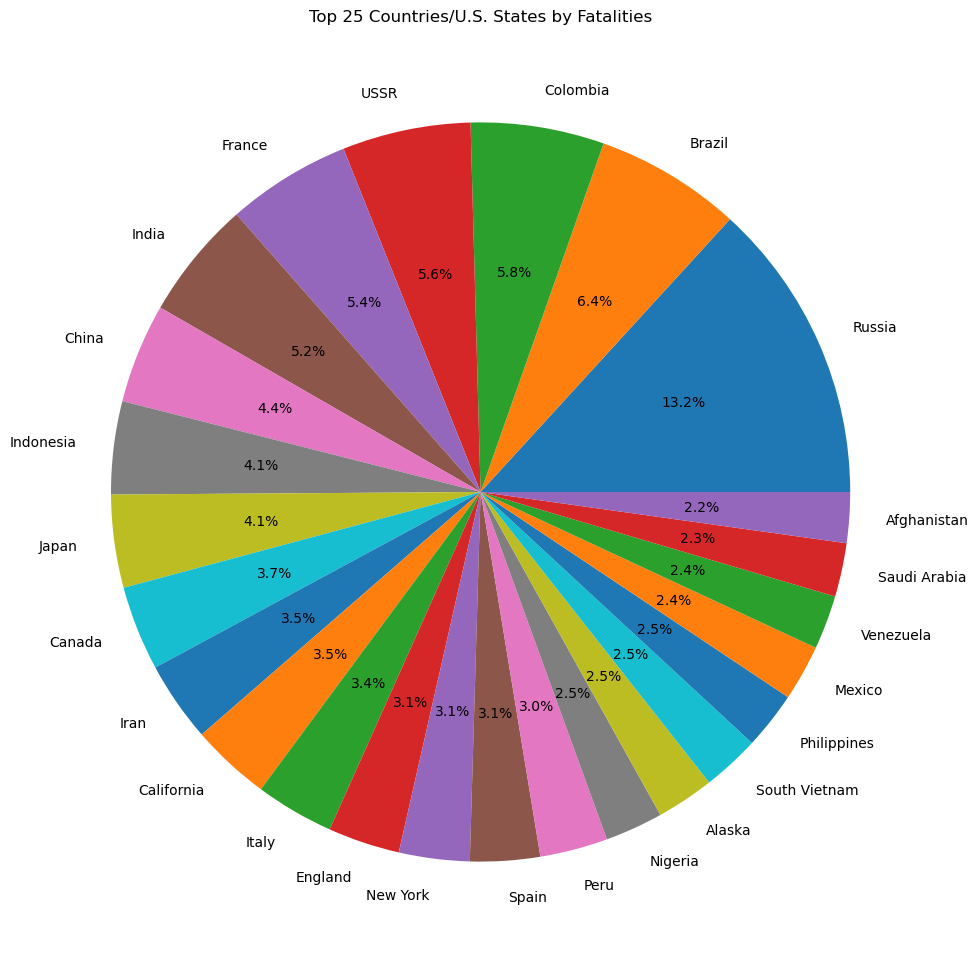

In [52]:
top_25 = (
    fatality_locations
    .groupby('State_Country')['Fatalities']
    .sum()
    .sort_values(ascending=False)
    .head(25)
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 12))

plt.pie(
    top_25.values,
    labels=top_25.index,
    autopct='%1.1f%%'
)

plt.title('Top 25 Countries/U.S. States by Fatalities')
plt.show()

